# DeepMine Analytics — Week 2: Feature Analysis & Correlation
**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Author:** Kingston Arockiasamy

---

## Objective
Identify which sensor features are the strongest predictors of machine failure.  
This analysis determines which variables to prioritise when building our ML model in Week 3.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ai4i2020.csv')

## Task 1.1 — Analyse Key Features by Machine Failure Status

This section compares the average values of important machine sensor features for machines that failed and machines that did not fail.

The selected features are:

- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]

The purpose of this analysis is to understand whether failed machines show different sensor behaviour compared with machines that did not fail.

In [2]:
# Average of all sensor readings: failed vs didn't fail
features = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

feature_avg = df.groupby('Machine failure')[features].mean()
feature_avg = feature_avg.rename(index={0: "Didn't fail", 1: "Failed"})
print(feature_avg)

                 Air temperature [K]  Process temperature [K]  \
Machine failure                                                 
Didn't fail               299.973999               309.995570   
Failed                    300.886431               310.290265   

                 Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
Machine failure                                                        
Didn't fail                 1540.260014    39.629655       106.693717  
Failed                      1496.486726    50.168142       143.781711  


### Interpretation

The results show that failed machines have slightly higher air temperature and process temperature compared with machines that did not fail. However, the difference in temperature is small.

Failed machines also have lower average rotational speed compared with machines that did not fail.

The main differences are seen in torque and tool wear. Failed machines have a higher average torque value and higher average tool wear. This suggests that torque and tool wear may be more important features when analysing machine failure.

Overall, machines that failed appear to have higher torque and higher tool wear, which may indicate greater mechanical stress before failure.

## Task 1.2 — Correlation Heatmap

This section analyses the correlation between the main numerical machine features and machine failure.

The selected features are:

- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- Machine failure

A correlation heatmap is used to show how strongly each feature is related to the other features. The main purpose is to identify which feature has the strongest relationship with machine failure before building the machine learning model.

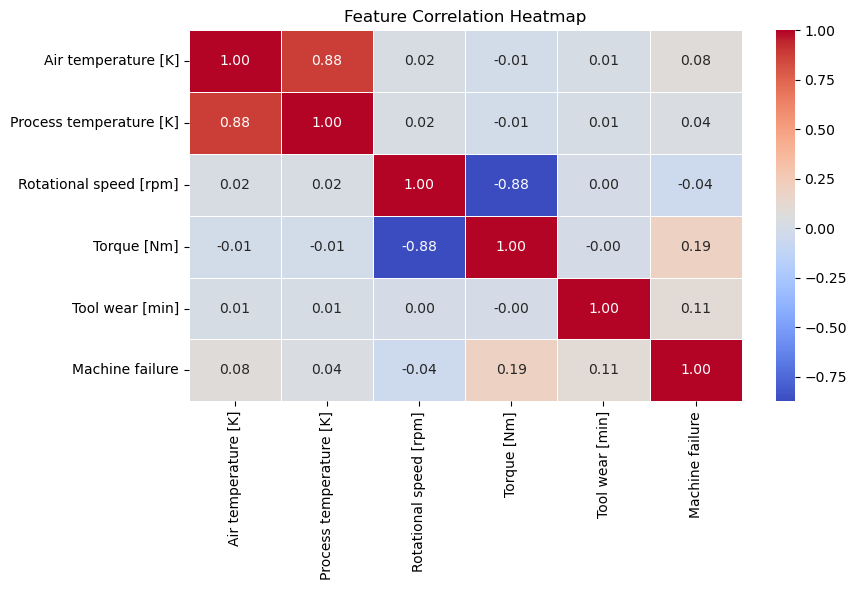

In [3]:
# Select only numeric sensor columns + failure column
corr_cols = ['Air temperature [K]', 'Process temperature [K]',
             'Rotational speed [rpm]', 'Torque [Nm]', 
             'Tool wear [min]', 'Machine failure']

# Calculate correlation
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Correlation with Machine Failure

After creating the heatmap, the correlation values for `Machine failure` are extracted separately. This makes it easier to compare each feature directly with machine failure and identify the strongest related feature.

In [4]:
# Extract correlation of each feature with Machine failure only
failure_corr = corr_matrix['Machine failure'].drop('Machine failure')
print(failure_corr)

Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Name: Machine failure, dtype: float64


In [5]:
strongest_feature = failure_corr.abs().idxmax()
strongest_value = failure_corr[strongest_feature]

print("Strongest predictor of machine failure:", strongest_feature)
print("Correlation value:", strongest_value)

Strongest predictor of machine failure: Torque [Nm]
Correlation value: 0.1913207750594941


### Interpretation

The correlation heatmap shows the relationship between each numerical feature and machine failure.

From the machine failure correlation values, `Torque [Nm]` has the strongest relationship with machine failure, with a correlation value of approximately 0.19. This means torque has the highest linear relationship with machine failure compared with the other selected features.

`Tool wear [min]` also shows some relationship with machine failure, with a correlation value of approximately 0.11. Air temperature and process temperature have weaker positive relationships, while rotational speed has a very weak negative relationship.

However, the correlation values are still small. This means that machine failure is not strongly explained by one single feature alone. Instead, machine failure may depend on a combination of multiple features.

Overall, torque appears to be the strongest linear predictor of machine failure among the selected numerical features.

## Task 1.3 — Box Plots by Machine Failure Status

This section uses box plots to compare the distribution of important machine features between failed and non-failed machines.

The selected features are:

- Torque [Nm]
- Rotational speed [rpm]
- Tool wear [min]

Box plots are useful because they show not only the average behaviour, but also the spread, median, and outliers in the data. This helps identify whether failed machines have different feature patterns compared with machines that did not fail.

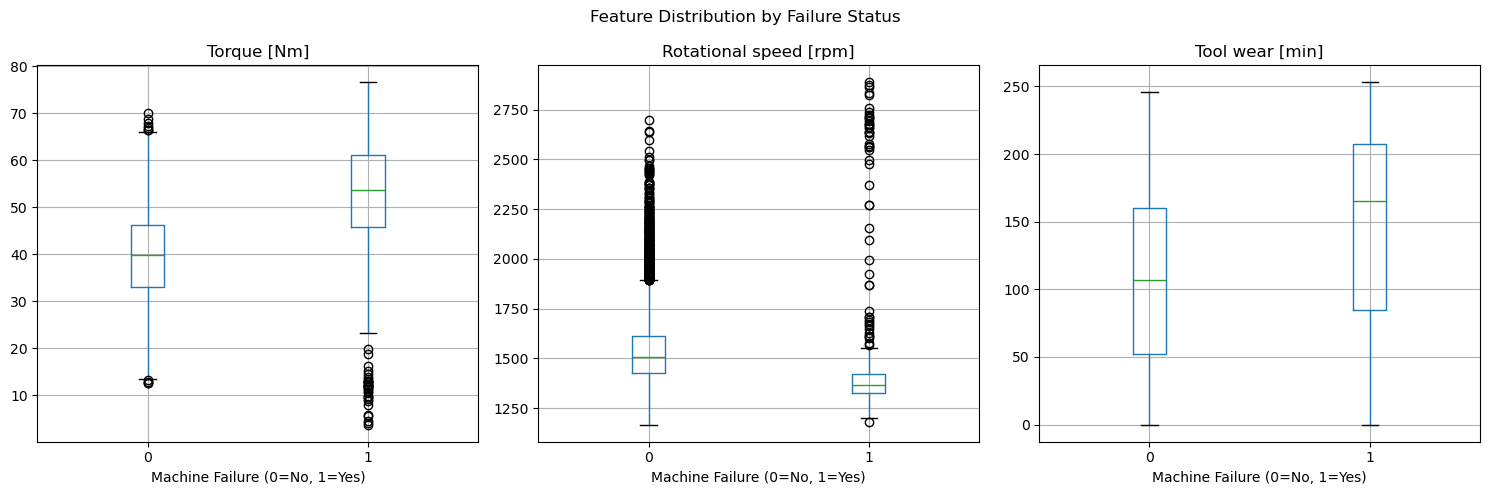

In [6]:
# Box plots for each feature split by failure status
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features_to_plot = ['Torque [Nm]', 'Rotational speed [rpm]', 'Tool wear [min]']

for ax, feature in zip(axes, features_to_plot):
    df.boxplot(column=feature, by='Machine failure', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Machine Failure (0=No, 1=Yes)')

plt.suptitle('Feature Distribution by Failure Status')
plt.tight_layout()
plt.show()

### Interpretation

The box plots compare feature values for machines that did not fail (`0`) and machines that failed (`1`).

From the torque box plot, failed machines show higher torque values compared with machines that did not fail. This suggests that machines with higher torque may have a greater chance of failure.

From the rotational speed box plot, failed machines generally have lower rotational speed compared with non-failed machines. This indicates that lower rotational speed may be associated with machine failure.

From the tool wear box plot, failed machines show higher tool wear values. This suggests that machines with more tool wear are more likely to fail.

Overall, the box plots show that failed machines tend to have higher torque, higher tool wear, and lower rotational speed. These features may be useful for predicting machine failure.

## Week 2 Summary — Key Findings

| Feature | Avg (No Failure) | Avg (Failed) | Correlation |
|---------|-----------------|--------------|-------------|
| Torque [Nm] | 39.63 | 50.17 | **0.19 (strongest)** |
| Tool wear [min] | 106.69 | 143.78 | 0.11 |
| Air temperature [K] | 299.97 | 300.89 | 0.08 |
| Rotational speed [rpm] | 1540.26 | 1496.49 | -0.04 |
| Process temperature [K] | 309.99 | 310.29 | 0.04 (weakest) |

### Key Takeaways
- **Torque** is the strongest predictor — failed machines average 10.5 Nm higher
- **Tool wear** is second — failed machines ran 37 minutes longer before breaking
- **Rotational speed** is negatively correlated — machines slow down under stress
- All correlations are below 0.20 — no single feature predicts failure alone
- **Week 3 implication:** We must combine all features together in one ML model

---